# Decision Making Tutorial 

We will learn how to calculate key decision making variables: psychometric and neurometric functions. 

We use the same dataset as in the previous tutorial. The roadmap is:  
Section 1. introduces the data collection procedure, provides some references and loads some useful libraries.   
Section 2. you load the data and familiarizes with its structure  
Sec. 3. Calculates the Psychometric curve  
Sec. 4. illustrates the contrast tuning of visual cortical neurons  
Sec. 5. Calculates the neurometric curve for an example neuron  
Sec. 6. gives you some independent work that you need to do during the course to demonstrate that you understand the data structure   
Finally, the last chapter describes the homework problems.


prepared by Balazs B Ujfalussy, 2026. balazs.ujfalussy@gmail.com, https://koki.hun-ren.hu/researchgroups/biological-computation/people#ujfalussy-balazs-skgtwtfggo3ftg9p


# Cortical and subcortical activity in a visual discrimination task from mice
source: Steinmetz database from https://compneuro.neuromatch.io/projects/neurons/README.html

## 1. About the data
Description form the Neuromatch website: *The Steinmetz dataset contains 39 Neuropixels recordings of 400-700 neurons each from across the mouse brain during a visual behavior task. This dataset is great for exploratory analyses and is relatively well supported with code and included many experimental and behavioral variables. You should still try to ask specific questions, i.e.: “does the superior colliculus offer a parallel or complementary visual processing pathway to visual cortex?”*

Credit for data curation: Marius Pachitariu, Scott Linderman

- Steinmetz, N. A., Zatka-Haas, P., Carandini, M., and Harris, K. D. (2019). Distributed coding of choice, action and engagement across the mouse brain. Nature, 576(7786): 266-273. doi: 10.1038/s41586-019-1787-x https://www.nature.com/articles/s41586-019-1787-x

### Load some useful libraries

*numpy* - to work with arrays (https://numpy.org/), *matplotlib* - to create simple plots (https://matplotlib.org/), *scipy.interpolate* to convert from time to position (https://docs.scipy.org/doc/scipy/reference/interpolate.html)

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import norm
import os, requests

%matplotlib widget

import scipy.sparse as sps
from collections import defaultdict
from random import sample

# from pyglmnet import GLM, simulate_glm

## 2. Retrieving and loading the data

In [2]:
# Data retrieval: uncomment all the following lines - only needed once

fname = []
for j in range(3):
  fname.append('steinmetz_part%d.npz'%j)
# url = ["https://osf.io/agvxh/download"]
# url.append("https://osf.io/uv3mw/download")
# url.append("https://osf.io/ehmw2/download")

# for j in range(len(url)):
#   if not os.path.isfile(fname[j]):
#     try:
#       r = requests.get(url[j])
#     except requests.ConnectionError:
#       print("!!! Failed to download data !!!")
#     else:
#       if r.status_code != requests.codes.ok:
#         print("!!! Failed to download data !!!")
#       else:
#         with open(fname[j], "wb") as fid:
#           fid.write(r.content)

In [3]:
# Data loading
alldat = np.array([])
for j in range(len(fname)):
  alldat = np.hstack((alldat,
                      np.load('../../ml4nda/Notebooks/datasets/Steinmetz/steinmetz_part%d.npz'%j,
                              allow_pickle=True)['dat']))

### Data description

alldat contains 39 sessions from 10 mice, data from Steinmetz et al, 2019. Time bins for all measurements are 10ms, starting 500ms before stimulus onset. The mouse had to determine which side has the highest contrast. For each dat = alldat[k], you have the fields below. For extra variables, check out the extra notebook and extra data files (lfp, waveforms and exact spike times, non-binned).

    dat['mouse_name']: mouse name
    dat['date_exp']: when a session was performed
    dat['spks']: neurons by trials by time bins.
    dat['brain_area']: brain area for each neuron recorded.
    dat['ccf']: Allen Institute brain atlas coordinates for each neuron.
    dat['ccf_axes']: axes names for the Allen CCF.
    dat['contrast_right']: contrast level for the right stimulus, which is always contralateral to the recorded brain areas.
    dat['contrast_left']: contrast level for left stimulus.
    dat['gocue']: when the go cue sound was played.
    dat['response_time']: when the response was registered, which has to be after the go cue. The mouse can turn the wheel before the go cue (and nearly always does!), but the stimulus on the screen won't move before the go cue.
    dat['response']: which side the response was (-1, 0, 1). When the right-side stimulus had higher contrast, the correct choice was -1. 0 is a no go response.
    dat['feedback_time']: when feedback was provided.
    dat['feedback_type']: if the feedback was positive (+1, reward) or negative (-1, white noise burst).
    dat['wheel']: turning speed of the wheel that the mice uses to make a response, sampled at 10ms.
    dat['pupil']: pupil area (noisy, because pupil is very small) + pupil horizontal and vertical position.
    dat['face']: average face motion energy from a video camera.
    dat['licks']: lick detections, 0 or 1.
    dat['trough_to_peak']: measures the width of the action potential waveform for each neuron. Widths <=10 samples are "putative fast spiking neurons".
    dat['%X%_passive']: same as above for X = {spks, pupil, wheel, contrast_left, contrast_right} but for passive trials at the end of the recording when the mouse was no longer engaged and stopped making responses.
    dat['prev_reward']: time of the feedback (reward/white noise) on the previous trial in relation to the current stimulus time.
    dat['reaction_time']: ntrials by 2. First column: reaction time computed from the wheel movement as the first sample above 5 ticks/10ms bin. Second column: direction of the wheel movement (0 = no move detected).

The original dataset is here: https://figshare.com/articles/dataset/Dataset_from_Steinmetz_et_al_2019/9598406


### Make a plot of which brain areas are present in each dataset


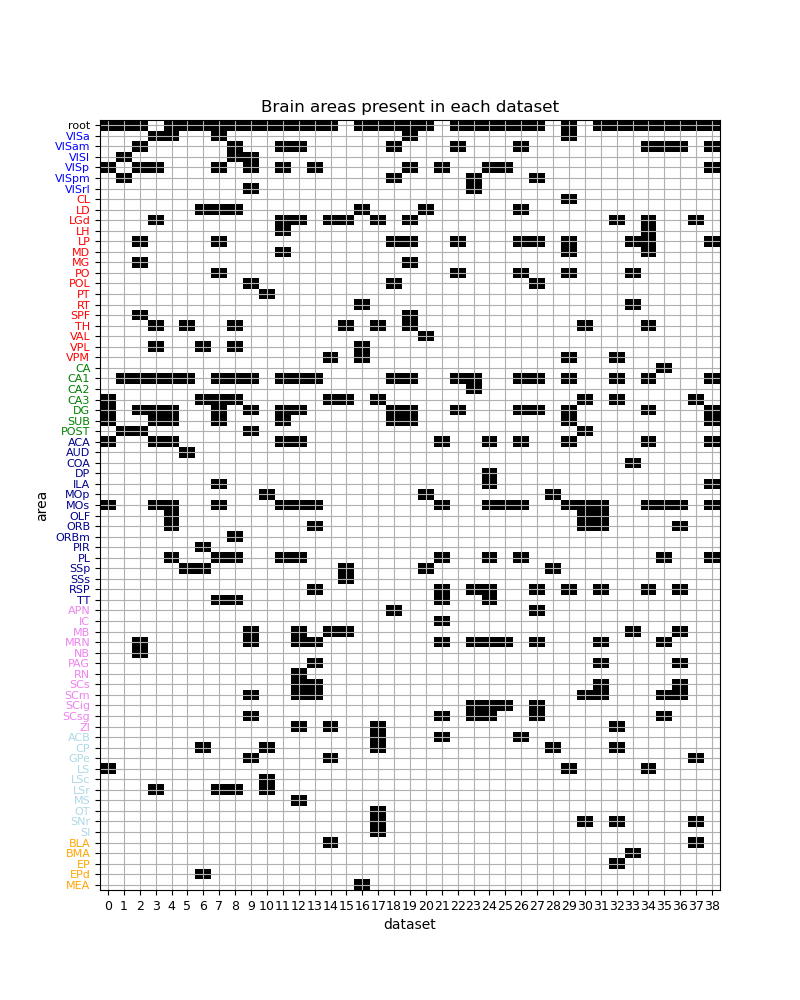

In [4]:
# note that region 4 ("other ctx" are neurons that were not able to be classified)
# region 4 does not correspond to brain_group 4, which are all cortical neurons outside of visual cortex
regions = ["vis ctx", "thal", "hipp", "other ctx", "midbrain", "basal ganglia", "cortical subplate", "other"]
region_colors = ['blue', 'red', 'green', 'darkblue', 'violet', 'lightblue', 'orange', 'gray']
brain_groups = [["VISa", "VISam", "VISl", "VISp", "VISpm", "VISrl"],  # visual cortex
                ["CL", "LD", "LGd", "LH", "LP", "MD", "MG", "PO", "POL", "PT", "RT", "SPF", "TH", "VAL", "VPL", "VPM"], # thalamus
                ["CA", "CA1", "CA2", "CA3", "DG", "SUB", "POST"],  # hippocampal
                ["ACA", "AUD", "COA", "DP", "ILA", "MOp", "MOs", "OLF", "ORB", "ORBm", "PIR", "PL", "SSp", "SSs", "RSP","TT"],  # non-visual cortex
                ["APN", "IC", "MB", "MRN", "NB", "PAG", "RN", "SCs", "SCm", "SCig", "SCsg", "ZI"],  # midbrain
                ["ACB", "CP", "GPe", "LS", "LSc", "LSr", "MS", "OT", "SNr", "SI"],  # basal ganglia
                ["BLA", "BMA", "EP", "EPd", "MEA"]  # cortical subplate
                ]

# Assign each area an index
area_to_index = dict(root=0)
counter = 1
for group in brain_groups:
    for area in group:
        area_to_index[area] = counter
        counter += 1

# Figure out which areas are in each dataset
areas_by_dataset = np.zeros((counter, len(alldat)), dtype=bool)
for j, d in enumerate(alldat):
    for area in np.unique(d['brain_area']):
        i = area_to_index[area]
        areas_by_dataset[i, j] = True

# Show the binary matrix
plt.figure(figsize=(8, 10))
plt.imshow(areas_by_dataset, cmap="Greys", aspect="auto", interpolation="none")

# Label the axes
plt.xlabel("dataset")
plt.ylabel("area")

# Add tick labels
yticklabels = ["root"]
for group in brain_groups:
  yticklabels.extend(group)
plt.yticks(np.arange(counter), yticklabels, fontsize=8)
plt.xticks(np.arange(len(alldat)), fontsize=9)

# Color the tick labels by region
ytickobjs = plt.gca().get_yticklabels()
ytickobjs[0].set_color("black")
counter = 1
for group, color in zip(brain_groups, region_colors):
  for area in group:
    ytickobjs[counter].set_color(color)
    counter += 1

plt.title("Brain areas present in each dataset")
plt.grid(True)
# plt.savefig('datasets/Steinmetz/brain_regions.pdf')

In [5]:
# select just one of the recordings here. 11 is nice because it has some neurons in vis ctx.
dat = alldat[11] ## dat['spks'].shape: neurons by trials by time bins; 698 x 340 x 250.
print(dat.keys())


dict_keys(['spks', 'wheel', 'pupil', 'response', 'response_time', 'bin_size', 'stim_onset', 'contrast_right', 'contrast_left', 'brain_area', 'feedback_time', 'feedback_type', 'gocue', 'mouse_name', 'date_exp', 'trough_to_peak', 'active_trials', 'contrast_left_passive', 'contrast_right_passive', 'spks_passive', 'pupil_passive', 'wheel_passive', 'prev_reward', 'ccf', 'ccf_axes', 'cellid_orig', 'reaction_time', 'face', 'face_passive', 'licks', 'licks_passive'])


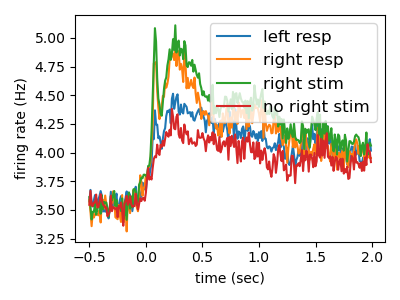

In [6]:
dt = dat['bin_size']  # binning at 10 ms
NT = dat['spks'].shape[-1] # number of time bins
timeaxis = np.arange(NT) * dt - 0.5


fig, ax = plt.subplots(figsize=(4,3))
response = dat['response']  # right - nogo - left (-1, 0, 1)
vis_right = dat['contrast_right']  # 0 - low - high
vis_left = dat['contrast_left']  # 0 - low - high
ax.plot(timeaxis, 1/dt * dat['spks'][:, response >= 0].mean(axis=(0, 1)))  # left responses
ax.plot(timeaxis, 1/dt * dat['spks'][:, response < 0].mean(axis=(0, 1)))  # right responses
ax.plot(timeaxis, 1/dt * dat['spks'][:, vis_right > 0].mean(axis=(0, 1)))  # stimulus on the right
ax.plot(timeaxis, 1/dt * dat['spks'][:, vis_right == 0].mean(axis=(0, 1)))  # no stimulus on the right

ax.legend(['left resp', 'right resp', 'right stim', 'no right stim'], fontsize=12)
ax.set(xlabel='time (sec)', ylabel='firing rate (Hz)')
fig.tight_layout()
# plt.savefig('datasets/Steinmetz/ave_stim_resp.pdf')

### Plots by brain region and visual conditions

In [17]:
nareas = 4  # only the top 4 regions are in this particular mouse
NN = len(dat['brain_area'])  # number of neurons
barea = nareas * np.ones(NN, )  # last one is "other"
for j in range(nareas):
  barea[np.isin(dat['brain_area'], brain_groups[j])] = j  # assign a number to each region

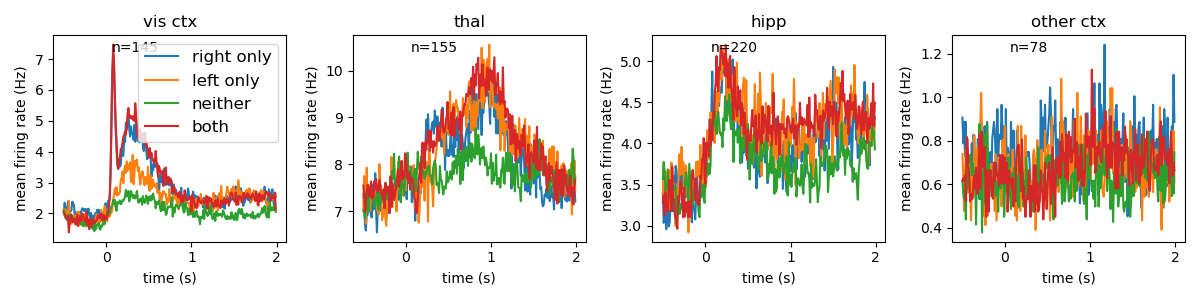

In [183]:
fig, axs = plt.subplots(1, nareas, figsize=(12, 3), sharey=False)

for j in range(nareas):
  axs[j].plot(timeaxis, 1/dt * dat['spks'][barea==j][:, np.logical_and(vis_left == 0, vis_right > 0)].mean(axis=(0, 1)))
  axs[j].plot(timeaxis, 1/dt * dat['spks'][barea==j][:, np.logical_and(vis_left > 0, vis_right == 0)].mean(axis=(0, 1)))
  axs[j].plot(timeaxis, 1/dt * dat['spks'][barea==j][:, np.logical_and(vis_left == 0, vis_right == 0)].mean(axis=(0, 1)))
  axs[j].plot(timeaxis, 1/dt * dat['spks'][barea==j][:, np.logical_and(vis_left > 0, vis_right > 0)].mean(axis=(0, 1)))
  axs[j].text(.25, .92, 'n=%d'%np.sum(barea == j), transform=axs[j].transAxes)

  if j==0:
    axs[j].legend(['right only', 'left only', 'neither', 'both'], fontsize=12)
  axs[j].set(xlabel='time (s)', ylabel='mean firing rate (Hz)', title=regions[j])
plt.tight_layout()
# plt.savefig('datasets/Steinmetz/resp_areas.pdf')

### Plot the responses in different visual areas 

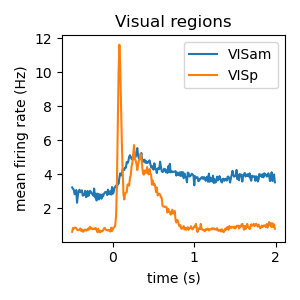

In [184]:
## responses for different visual areas
visual = brain_groups[0] + ['SCs']

fig, axs = plt.subplots(1, 1, figsize=(3, 3), sharey=False)

for j, varea in enumerate(visual):
    areaindex = dat['brain_area'] == varea
    if (np.sum(areaindex) > 0):
        axs.plot(timeaxis, 1/dt * dat['spks'][areaindex][:, vis_right > 0].mean(axis=(0, 1)), label=varea)

axs.legend()
axs.set(xlabel='time (s)', ylabel='mean firing rate (Hz)', title='Visual regions')
fig.tight_layout()

### Plots by brain region and response type

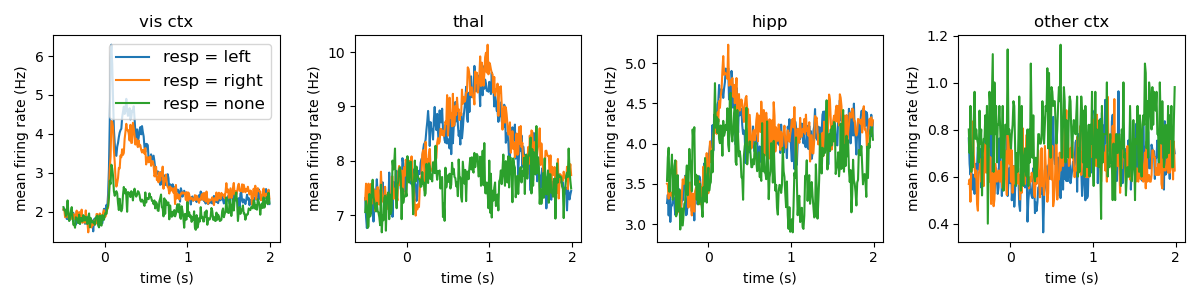

In [185]:
fig, axs = plt.subplots(1, nareas, figsize=(12, 3), sharey=False)

for j in range(nareas):
  axs[j].plot(timeaxis, 1/dt * dat['spks'][barea == j][:, response < 0].mean(axis=(0, 1)))
  axs[j].plot(timeaxis, 1/dt * dat['spks'][barea == j][:, response > 0].mean(axis=(0, 1)))
  axs[j].plot(timeaxis, 1/dt * dat['spks'][barea == j][:, response == 0].mean(axis=(0, 1)))

  if j==0:
    axs[j].legend(['resp = left', 'resp = right', 'resp = none'], fontsize=12)
  axs[j].set(xlabel='time (s)', ylabel='mean firing rate (Hz)', title=regions[j])
plt.tight_layout()
# plt.savefig('datasets/Steinmetz/resp_areas_resp.pdf')

## 3. Decision variables

In [7]:
# Performance of the mice
names=list()
perf = list()

for i_session in range(len(alldat)):
    dat = alldat[i_session] ## dat['spks'].shape: neurons by trials by time bins; 698 x 340 x 250.
    names.append(dat['mouse_name'])
    p_correct = np.sum(dat['feedback_type'] == 1) / len(dat['feedback_type'])
    perf.append(p_correct)

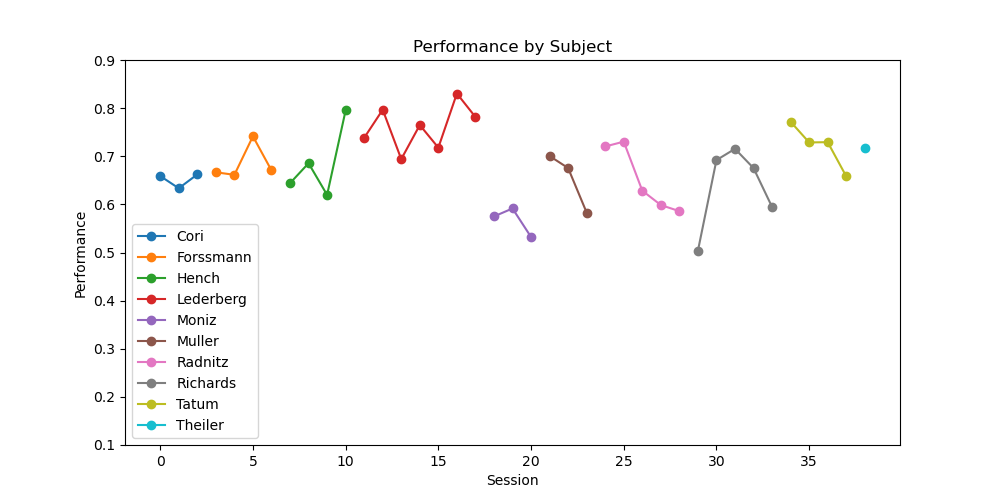

In [11]:

# Group performances by subject
f, ax = plt.subplots(figsize=(10, 5))
data = defaultdict(list)
for s, p in zip(names, perf):
    data[s].append(p)

# Plot
i0 = 0
for subject, performance in data.items():
    ax.plot(np.arange(len(performance)) + i0, performance, marker='o', label=subject)
    i0 = i0 + len(performance)
    
ax.set(xlabel = "Session", ylabel="Performance",title="Performance by Subject", ylim=(0.1, 0.9))
plt.legend(loc = 'lower left')



### 3.1. Psychometric curves

Lederberg 2017-12-05 P correct = 0.74


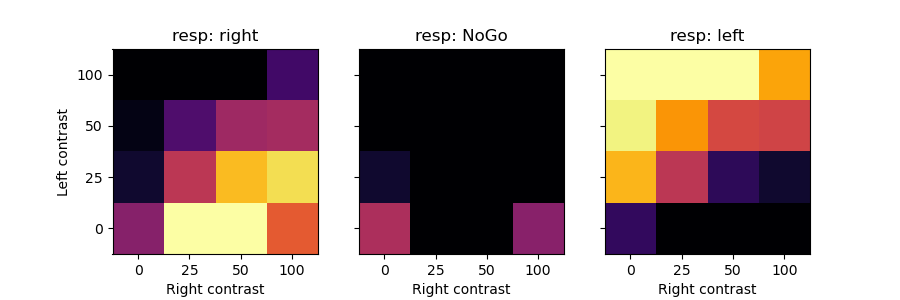

In [75]:
# select just one of the recordings here. 11 is nice because it has some neurons in vis ctx.
# session 17 has a good performance, but no visual neurons
# session 25 has nice psychometric curve, good visual neurons
dat = alldat[11] ## dat['spks'].shape: neurons by trials by time bins; 698 x 340 x 250.

contrast_levels = np.unique(dat['contrast_left'])
nstim = np.zeros((4,4))
nright = np.zeros((4,4))
nleft = np.zeros((4,4))
nNoGo = np.zeros((4,4))

for i_level_left in np.arange(4):
    for i_level_right in np.arange(4):
        c_left_right = np.logical_and(dat['contrast_left'] == contrast_levels[i_level_left], dat['contrast_right'] == contrast_levels[i_level_right])
        nstim[i_level_left, i_level_right] = np.sum(c_left_right)
        nright[i_level_left, i_level_right] = np.sum(dat['response'][c_left_right] == -1)
        nleft[i_level_left, i_level_right] = np.sum(dat['response'][c_left_right] == 1)
        nNoGo[i_level_left, i_level_right] = np.sum(dat['response'][c_left_right] == 0)

fig, axs = plt.subplots(1, 3, figsize=(9, 3), sharey=True, sharex=True)

axs[0].imshow((nright/nstim), cmap='inferno', origin='lower', vmin=0, vmax=1)
axs[0].set(xticks = [0,1,2,3], xticklabels=['0', '25', '50', '100'], xlabel='Right contrast',
           yticks = [0,1,2,3], yticklabels=['0', '25', '50', '100'], ylabel='Left contrast', title='resp: right')

axs[1].imshow((nNoGo/nstim), cmap='inferno', origin='lower', vmin=0, vmax=1)
axs[1].set(xticks = [0,1,2,3], xticklabels=['0', '25', '50', '100'], xlabel='Right contrast', title='resp: NoGo')

axs[2].imshow((nleft/nstim), cmap='inferno', origin='lower', vmin=0, vmax=1)
axs[2].set(xticks = [0,1,2,3], xticklabels=['0', '25', '50', '100'], xlabel='Right contrast', title='resp: left')

p_correct = np.sum(dat['feedback_type'] == 1) / len(dat['feedback_type'])
print(dat['mouse_name'], dat['date_exp'], f"P correct = {p_correct:.2f}")



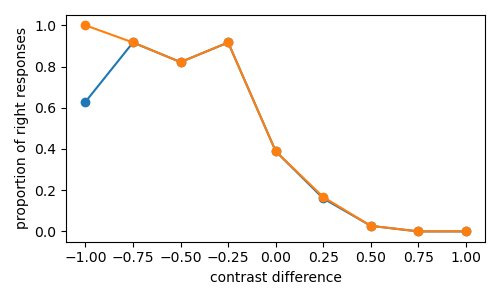

In [76]:
dcontrast = dat['contrast_left'] - dat['contrast_right']
levels = np.unique(dcontrast)
propright = np.zeros_like(levels)
propright2 = np.zeros_like(levels)

for i, level in enumerate(levels):
    if (level == 0):
        index = np.flatnonzero((dcontrast == level) & (np.abs(dat['contrast_left']) > 0)) # we do not include when both are 0
    else:
        index = np.flatnonzero(dcontrast == level)

    nright = np.sum(dat['response'][index] == -1)
    nleft = np.sum(dat['response'][index] == 1)
    propright[i] = nright / len(index)
    propright2[i] = nright / (nleft + nright)

f, ax = plt.subplots(figsize=(5, 3))
ax.plot(levels, propright, '-o')
ax.plot(levels, propright2, '-o')

ax.set(xlabel='contrast difference', ylabel='proportion of right responses')
f.tight_layout()

## 4. Contrast tuning - same as before

In the experiments neurons were recorded in the left side of the brain. 
Visual stimuli crosses the midline, so light from the right side arrives to the left hemisphere. 

Here we will start by plotting the response of different visual cortical neurons as a function of the contrast of the left or the right stimuli.

In [77]:
len(ii_highrate)

19

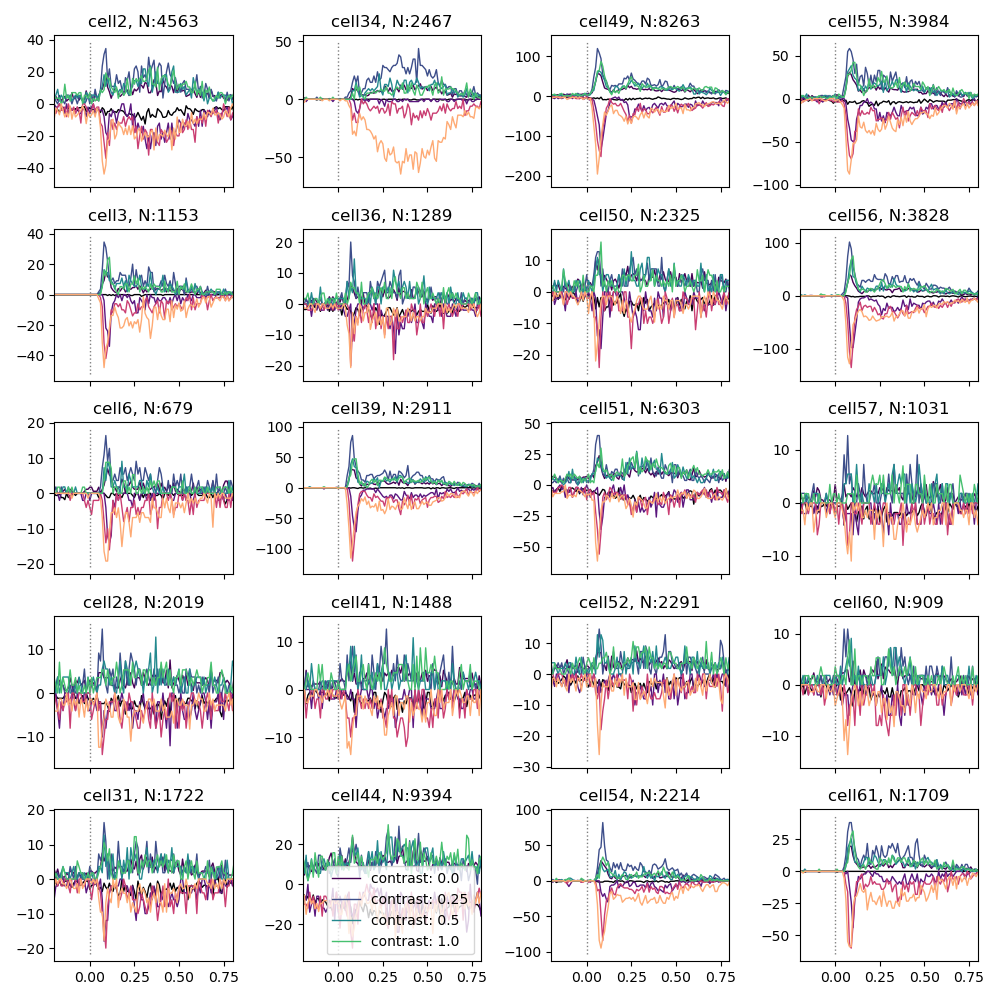

In [78]:
i_visual = np.flatnonzero(dat['brain_area'] == 'VISp') # select cells in the primary visual cortex - 66 cells
dat_vis = dat['spks'][i_visual,:,:] ## 66 x 340 x 250; cells x conditions x time
ii_highrate = np.flatnonzero(np.sum(dat_vis[:,:,40:110], axis=(1,2)) > 400)
dat_HR_vis = dat_vis[ii_highrate,:,:] ## 20 x 340 x 250; cells x conditions x time

contrast_levels = np.unique(dat['contrast_left'])
N_cells = dat_HR_vis.shape[0]
cmap = plt.colormaps['viridis']
cmap2 = plt.colormaps['magma']

fig, axs = plt.subplots(5, 4, figsize=(10, 10), sharey=False, sharex=True)
for i_cell in np.arange(N_cells):
    meanresp = np.zeros((4,4))
    i = i_cell % 5
    j = i_cell // 5
    
    for i_level in np.arange(4):
        c_left = dat['contrast_left'] == contrast_levels[i_level]
        c_right = dat['contrast_right'] == contrast_levels[i_level]
        labeltext = 'contrast: ' + str(contrast_levels[i_level])
            
        axs[i, j].plot(timeaxis, 1/dt * dat_HR_vis[i_cell, c_left,].mean(axis=0), color=cmap(i_level*60), label=labeltext, linewidth=1)
        axs[i, j].plot(timeaxis, -1 * 1/dt * dat_HR_vis[i_cell, c_right,].mean(axis=0), color=cmap2(i_level*70), linewidth=1)
        if (i_cell == 9): 
            axs[i, j].legend()
            
    titlestring = 'cell' + str(ii_highrate[i_cell]) + ', N:' + str(np.sum(dat_HR_vis[i_cell,:,:])) 
    ylims = axs[i,j].get_ylim()
    axs[i,j].vlines(0, ylims[0], ylims[1], color='grey', linestyle=':', linewidth=1)
    axs[i, j].set(title=titlestring, xlim=(-0.2, 0.8))

fig.tight_layout()

### Neural responses to different stimulus conditions

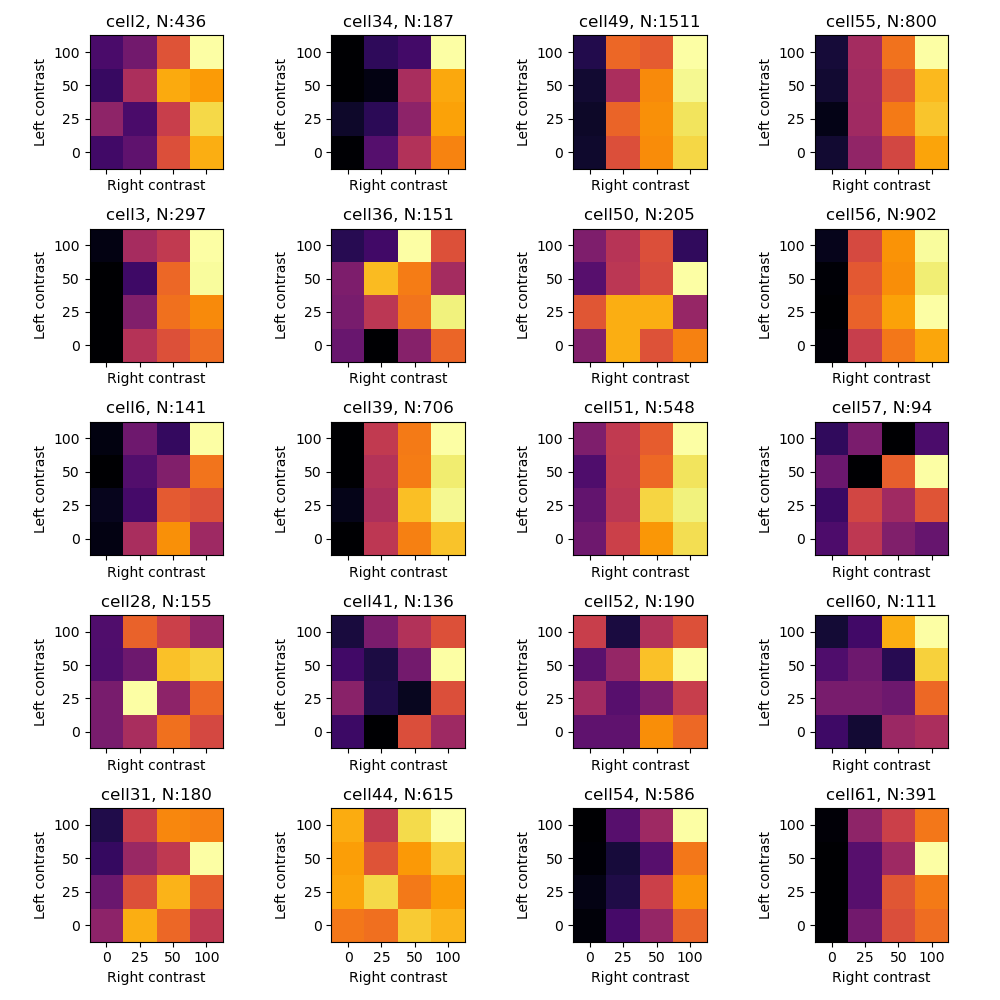

In [80]:
i_visual = np.flatnonzero(dat['brain_area'] == 'VISp') # select cells in the primary visual cortex - 66 cells
dat_vis = dat['spks'][i_visual,:,:] ## 66 x 340 x 250; cells x conditions x time
ii_highrate = np.flatnonzero(np.sum(dat_vis[:,:,40:110], axis=(1,2)) > 400)
dat_HR_vis = dat_vis[ii_highrate,:,:] ## 20 x 340 x 250; cells x conditions x time

contrast_levels = np.unique(dat['contrast_left'])
N_cells = dat_HR_vis.shape[0]

fig, axs = plt.subplots(5, 4, figsize=(10, 10), sharey=False, sharex=True)
for i_cell in np.arange(N_cells):
    meanresp = np.zeros((4,4))
    i = i_cell % 5
    j = i_cell // 5
    
    for i_level_left in np.arange(4):
        for i_level_right in np.arange(4):
            c_left_right = np.logical_and(dat['contrast_left'] == contrast_levels[i_level_left], dat['contrast_right'] == contrast_levels[i_level_right])
            meanresp[i_level_left, i_level_right] = np.mean(np.sum(dat_HR_vis[i_cell, c_left_right,50:65], axis=1))
            
    axs[i, j].imshow((meanresp), cmap='inferno', origin='lower', vmin=0)
    titlestring = 'cell' + str(ii_highrate[i_cell]) + ', N:' + str(np.sum(dat_HR_vis[i_cell,:,50:65])) 
    axs[i,j].set(xticks = [0,1,2,3], xticklabels=['0', '25', '50', '100'], xlabel='Right contrast',
               yticks = [0,1,2,3], yticklabels=['0', '25', '50', '100'], ylabel='Left contrast', title=titlestring)
            
fig.tight_layout()

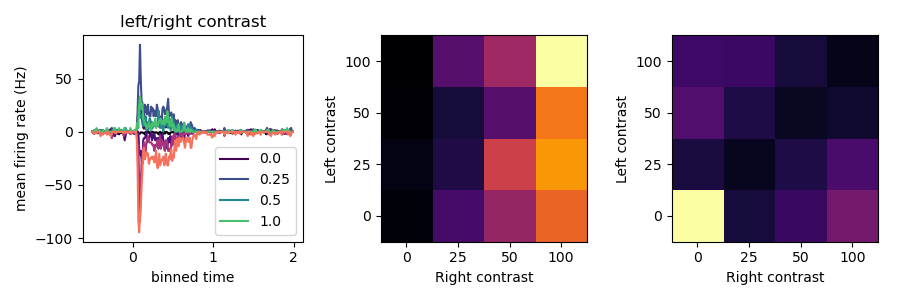

In [81]:
# neurons by trials by time bins.
dat_vis = dat['spks'][i_visual,:,:] ## 66 x 340 x 250
contrast_levels = np.unique(dat['contrast_left'])

# for i_cell in np.arange(N_cells)
i_cell = 54

meanresp = np.zeros((4,4))
nstim = np.zeros((4,4))

fig, axs = plt.subplots(1, 3, figsize=(9, 3), sharey=False)
for i_level in np.arange(4):
    c_left = dat['contrast_left'] == contrast_levels[i_level]
    c_right = dat['contrast_right'] == contrast_levels[i_level]
    axs[0].plot(timeaxis, 1/dt * dat_vis[i_cell, c_left,:].mean(axis=0), label=str(contrast_levels[i_level]), color=cmap(i_level*60))
    axs[0].plot(timeaxis, -1/dt * dat_vis[i_cell, c_right,:].mean(axis=0), color=cmap2(i_level*60))

for i_level_left in np.arange(4):
    for i_level_right in np.arange(4):
        c_left_right = np.logical_and(dat['contrast_left'] == contrast_levels[i_level_left], dat['contrast_right'] == contrast_levels[i_level_right])
        meanresp[i_level_left, i_level_right] = np.mean(np.sum(dat_vis[i_cell, c_left_right,50:65], axis=1))
        nstim[i_level_left, i_level_right] = np.sum(c_left_right)


axs[1].imshow((meanresp), cmap='inferno', origin='lower', vmin=0)
axs[1].set(xticks = [0,1,2,3], xticklabels=['0', '25', '50', '100'], xlabel='Right contrast',
           yticks = [0,1,2,3], yticklabels=['0', '25', '50', '100'], ylabel='Left contrast')

axs[2].imshow((nstim), cmap='inferno', origin='lower', vmin=0)
axs[2].set(xticks = [0,1,2,3], xticklabels=['0', '25', '50', '100'], xlabel='Right contrast',
           yticks = [0,1,2,3], yticklabels=['0', '25', '50', '100'], ylabel='Left contrast')

axs[0].legend()
axs[0].set(xlabel='binned time', ylabel='mean firing rate (Hz)', title='left/right contrast')
# axs[1].set(xlabel='binned time', title='right contrast', ylim=(-5, 70))  
fig.tight_layout()

## 5. Neurometric curve

In this dataset, we have neurons only from the left hemisphere. Essentially no neurons respond to the light in the left side of the visual plane. However, such neurons exist, and the mouse presumably uses them to make decisions. 

In order to calculate a neurometric curve, here we will use a trick: we will simulate an activity of a neuron similar to one of the recorded cells (e.g., cell 54|), just sitting in the left part of the brain, thus tuned to the left contrast. One can make a decision regarding the stimulus contrast by comparing the activity of these two neurons: the contrast if higher on the opposite side than where there are more spikes.

This approach makes the simplifying assumption, that the neurons in the two side are independent of each other, conditionned on the stimulus. This is clearly a simplification, but we will still work with this assumption anyway. 

Finally, for each stimulus condition one can either sample from the spike counts recorded for the particular stimulus value, or generate samples from the corresponding Poisson distribution. These two approaches have complementary advantages and drawbacks. 

Here we will implement a sampling from the empirical distribution and calculate the neurometric function. The task of the student is to implement the Poisson and compare the neurometric functions obtained by the two methods.

### Make a lists with the spike counts for each contrast pair

In [151]:
i_cell = 51 # 49, 51, 54 or 61
grouped_counts = defaultdict(list)
data_c_left = dat['contrast_left']
data_c_right = dat['contrast_right']
data_counts = np.sum(dat_vis[i_cell,:,50:65], axis=1)

for l, r, c in zip(data_c_left, data_c_right, data_counts):
    grouped_counts[(l, r)].append(c)

print(grouped_counts[(0.0, 0.5)])

[2, 3, 1, 3, 2, 3, 2, 3, 2, 3, 2, 3, 1, 0, 2, 4, 3, 2, 3]


### Simulate decisions based on these two cells

Now, we will generate data: for each contrast pairs, we will generate 100 simulations, where we sample from this spike patterns.

In [152]:
contrast_levels = np.unique(data_c_left)
N_levels = len(contrast_levels)
N_rep = 1000
N_sim = N_rep * N_levels * N_levels

contrast_left = np.zeros(N_sim)
contrast_right = np.zeros(N_sim)
spikes_left = np.zeros(N_sim)
spikes_right = np.zeros(N_sim)
decision = np.zeros(N_sim)

i = 0

for c_left in contrast_levels:
    for c_right in contrast_levels:
        for i_rep in np.arange(N_rep):
            contrast_left[i] = c_left
            contrast_right[i] = c_right
            spikes_right[i] = sample(grouped_counts[(c_left, c_right)], 1)[0]
            spikes_left[i] = sample(grouped_counts[(c_right, c_left)], 1)[0]
            if (spikes_left[i] == spikes_right[i]):
                decision[i] = sample([-1, 1], 1)[0]
            elif (spikes_left[i] < spikes_right[i]):
                decision[i] = -1
            else:
                decision[i] = 1
            i = i + 1
            

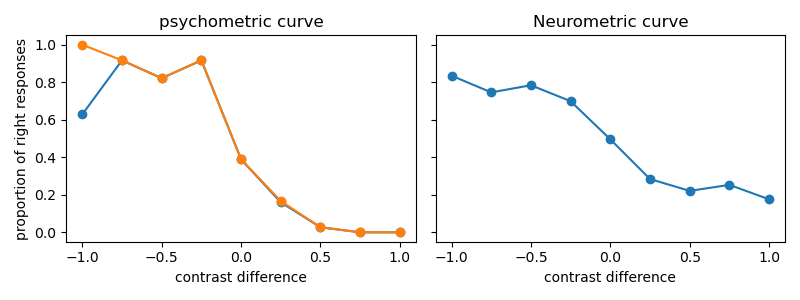

In [153]:
sim_dcontrast = contrast_left - contrast_right
levels = np.unique(sim_dcontrast)
sim_propright = np.zeros_like(levels)

for i, level in enumerate(levels):
    if (level == 0):
        index = np.flatnonzero((sim_dcontrast == level) & (np.abs(contrast_left) > 0)) # we do not include when both are 0
    else:
        index = np.flatnonzero(sim_dcontrast == level)

    nright = np.sum(decision[index] == -1)
    nleft = np.sum(decision[index] == 1)
    sim_propright[i] = nright / (nleft + nright)

f, ax = plt.subplots(1, 2, figsize=(8, 3), sharex = True, sharey=True)
ax[1].plot(levels, sim_propright, '-o')
ax[1].set(xlabel='contrast difference', ylabel='', title='Neurometric curve')



ax[0].plot(levels, propright, '-o')
ax[0].plot(levels, propright2, '-o')

ax[0].set(xlabel='contrast difference', ylabel='proportion of right responses', title='psychometric curve')
f.tight_layout()

## 6. Independent work

- Estimate the neurometric curve using Poisson simulations instead of the empirical count distribution. 
- Pick a few other real cells, and see how the neurometric function changes
- In reality the left and the right cells are not identical mirrors to each other. What would you do in this case, how would you make a decision? (Hint: think about the last exercise, using Bayesian inference.)

When answering the problem you are expected to 
- State the problem. What is the question you want to answer/understand/illustrate? Why is it relevant, why is it interesting?
- What are your expectations? Do you have any prior knowledge on the subject? Are you aware of any similar analysis?
- What are the methods you want to use to answer the question? Why did you chose those methods?
- Visualization. Plotting the results is important. Try to show your results in different ways: Provide as much access to the low level data as possible. Find an intuitive way to illustrate your conclusions and take home message.
- State the results of the analysis explicitely. Compare it with the expectations.
- Discuss the results. How did the whole process change the way you are thinking about the data and/or the analysis? Is there anything you would do in a different way?

# Homework problems

Choose one of the following:

## 1. Calculate the neurometric curve by using 2 or more neurons
Still use synthetic data, but now simulate the spiking of more neurons on both sides.  
First use the neurons to infer the posterior for the left and the right contrast.   
Then use these posteriors to make decisions.  
Calculate the accuracy as a function of the number of neurons.  
Compare the accuracy on the simulated data with the accuracy of the animal (consider the prior on the contrast levels).  
With how many neurons can you reach the accuracy of the animal?  

## 2. Speed-accuracy tradeof
Assume, that you want to achieve 90% accuracy in all cases where the contrast difference is not 0.   
How much time do you need to wait and collect spikes to achieve that? Use the Poisson model, and calculate accuracy analytically.  
Use simulations to check the accuracy of your calculations.  
Plot the neurometric curves and the decision times as a function of contrast difference.
Check how the average decision times depend on the contrast levels in the data.
You should look at the  
`dat['gocue']`: when the go cue sound was played.  
`dat['response_time']`: when the response was registered, which has to be after the go cue. The mouse can turn the wheel before the go cue (and nearly always does!), but the stimulus on the screen won't move before the go cue.

## 3. Drift-diffusion model simulations
Check the other notebook with the drift/diffusion model (`DecisionMaking_CompNeuro.ipynb`) and answer the questions there.

